<a href="https://colab.research.google.com/github/fajareka1/PCVK_Ganjil_2026_v2/blob/main/Modul1_Praktikum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#step 1
#consume library
import numpy as np
import pandas as pd
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
from skimage import transform
from PIL import Image
import matplotlib.pylab as plt


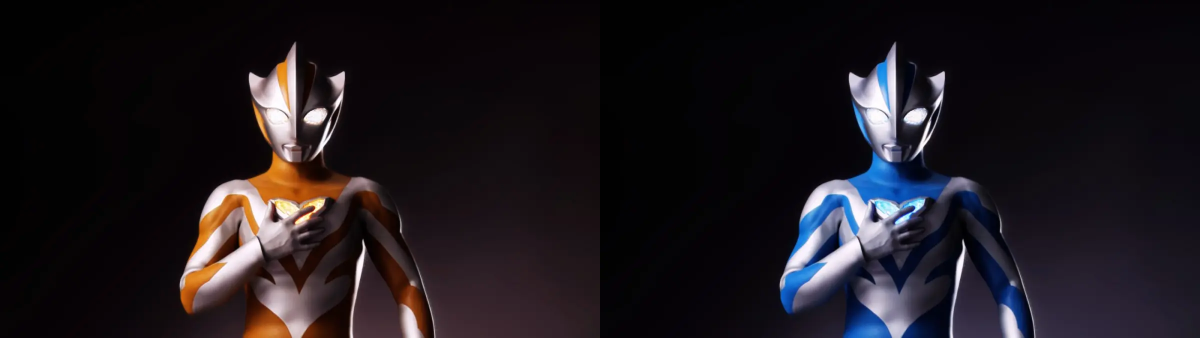

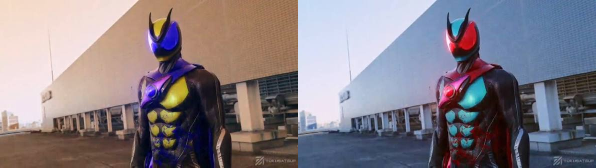

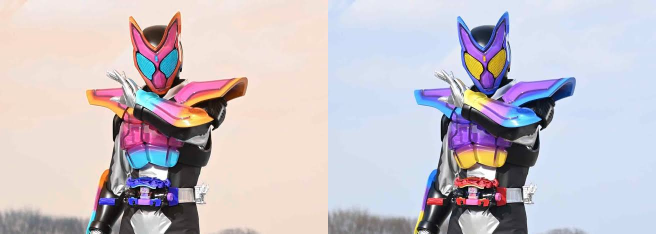

In [ ]:
urls = ["https://cdn-jjmn.jawapos.com/images/2/2026/04/21/ultraman-teo-Gi4fP.webp",
        "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSEMsi3E11ZrMGahby6gD0hIRWPjSOTK1jscoCrZZKTh8ZGPqg6gTrvmFk&s=10",
        "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQyBHnGTlt0gLIeiZ1596fGA8_69Q9wHMXOFLHAc4h84OEl5sB_Xz4oJwvg&s=10"]

for url in urls:
  image = io.imread(url)
  image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
  image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
  final_frame = cv.hconcat((image, image_2))
  cv2_imshow(final_frame)
  print('\n')

resolusi image : tinggi x lebar =  234  x  328


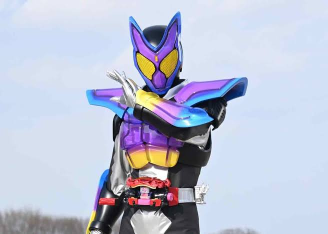

In [ ]:
tinggi = image_2.shape[0]
lebar = image_2.shape[1]
print("resolusi image : tinggi x lebar = ", tinggi, " x ", lebar)
cv2_imshow(image_2)

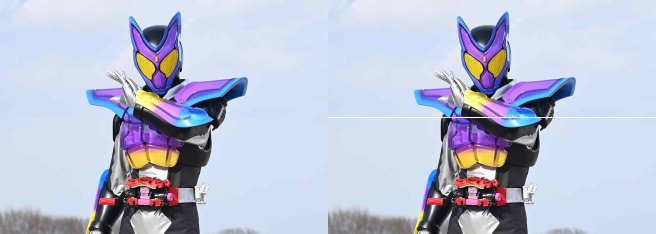

In [ ]:
image_2 = cv.cvtColor(image, cv.COLOR_BGR2RGB)
image_3 = cv.cvtColor(image, cv.COLOR_BGR2RGB)

#membuat garis tengah
for y in range (lebar):
  image_3[int((tinggi)/2),y] = [255, 255, 255]

final_frame = cv.hconcat((image_2, image_3))
cv2_imshow(final_frame)

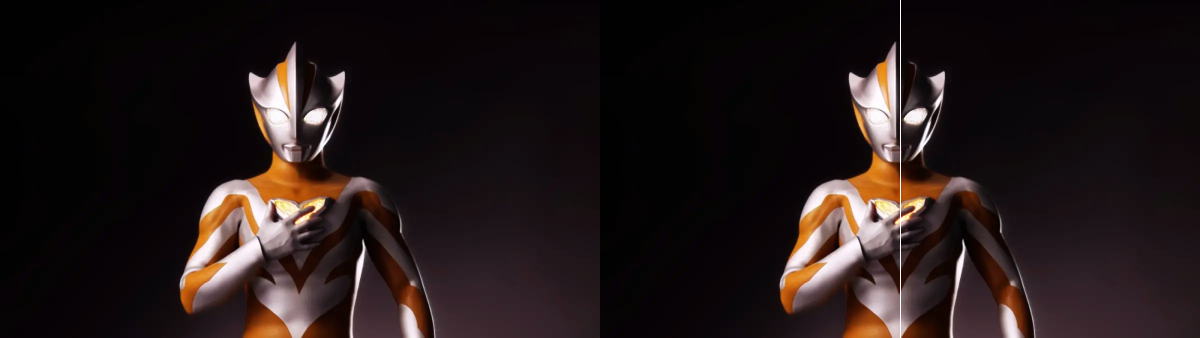

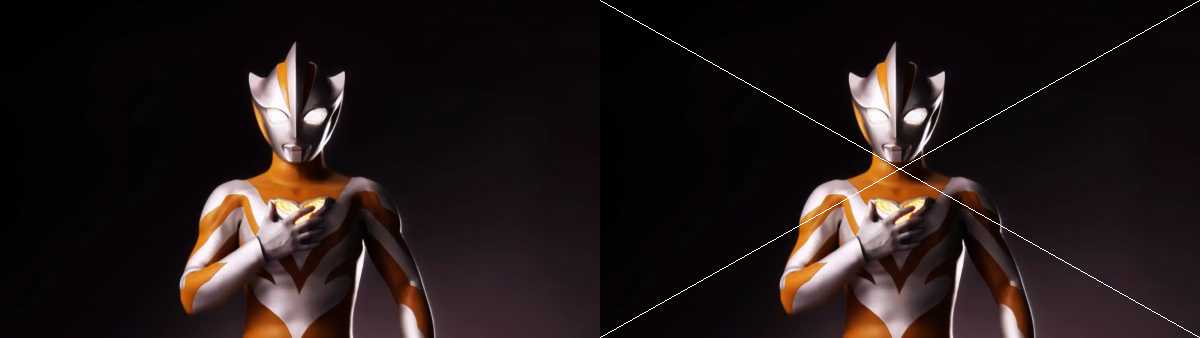

In [ ]:
image = io.imread(urls[0])
image = cv.resize(image, (0,0), fx=0.5, fy=0.5)
image_rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
tinggi, lebar = image_rgb.shape[0], image_rgb.shape[1]

# 2) Garis vertikal + garis menyilang diagonal
img_vertikal = image_rgb.copy()
for x in range(tinggi):
    img_vertikal[x, lebar//2] = [255, 255, 255]

cv2_imshow(cv.hconcat((cv.cvtColor(image_rgb, cv.COLOR_RGB2BGR),
                        cv.cvtColor(img_vertikal, cv.COLOR_RGB2BGR))))

img_diagonal = image_rgb.copy()
# Diagonal kiri atas → kanan bawah
cv.line(
    img_diagonal,
    (0, 0),
    (lebar - 1, tinggi - 1),
    (255, 255, 255),
    1
)

# Diagonal kanan atas → kiri bawah
cv.line(
    img_diagonal,
    (lebar - 1, 0),
    (0, tinggi - 1),
    (255, 255, 255),
    1
)

cv2_imshow(
    cv.hconcat((
        cv.cvtColor(image_rgb, cv.COLOR_RGB2BGR),
        cv.cvtColor(img_diagonal, cv.COLOR_RGB2BGR)
    ))
)


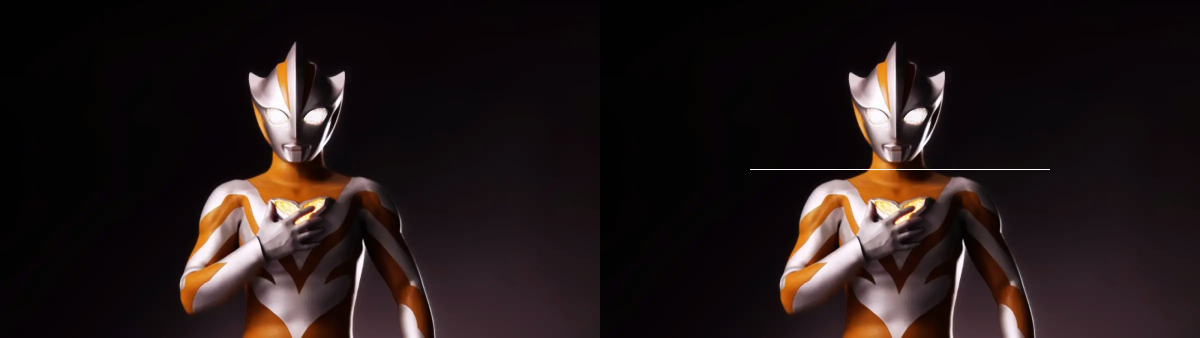

In [ ]:
# 3) Garis horizontal putih dengan panjang tertentu
img_garis_pendek = image_rgb.copy()

# Posisi garis tepat di tengah tinggi gambar
y_tengah = tinggi // 2

# Garis dimulai 25% dari kiri dan berakhir 75% dari kiri
x_mulai = int(lebar * 0.25)
x_akhir = int(lebar * 0.75)

# Membuat garis horizontal putih
for x in range(x_mulai, x_akhir):
    img_garis_pendek[y_tengah, x] = [255, 255, 255]

# Menampilkan gambar asli dan hasil
cv2_imshow(
    cv.hconcat((
        cv.cvtColor(image_rgb, cv.COLOR_RGB2BGR),
        cv.cvtColor(img_garis_pendek, cv.COLOR_RGB2BGR)
    ))
)

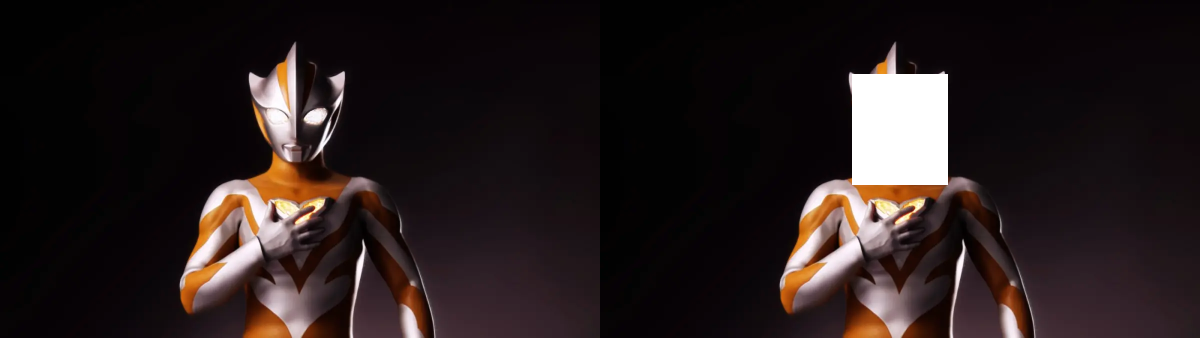

In [ ]:
# 4) Kotak (kumpulan pixel putih) di bagian muka
img_kotak = image_rgb.copy()

# Posisi kotak pada bagian muka
y1, y2 = int(tinggi * 0.22), int(tinggi * 0.55)
x1, x2 = int(lebar * 0.42), int(lebar * 0.58)

# Membuat kotak menjadi putih
img_kotak[y1:y2, x1:x2] = [255, 255, 255]

# Menampilkan gambar asli dan hasil
cv2_imshow(
    cv.hconcat((
        cv.cvtColor(image_rgb, cv.COLOR_RGB2BGR),
        cv.cvtColor(img_kotak, cv.COLOR_RGB2BGR)
    ))
)